# Annual Electricity Generation Source Proportions (NESO data)

<div class="alert alert-info">
  <strong>Author:</strong> James Fallon<br>
  <strong>Date:</strong> 2025-08-13<br>
  <strong>Python:</strong> <code>3.12.8</code>
</div>

Data source: https://www.neso.energy/data-portal/historic-generation-mix/historic_gb_generation_mix

Calculate the proportion of energy generated from different sources

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read NESO data
df = pd.read_csv("../data/df_fuel_ckan.csv", index_col="DATETIME", parse_dates=["DATETIME"]).sort_index()

# Select 2024/25 financial year
fy = "2024/25"
df = df.loc["2024-04-01":"2025-03-31"]
#fy = "2024"
#df = df.loc["2024"]

# Remove the _perc columns (energy generation percentage at a given time)
# as these aren't relevant to calculating the percentage of total annual generation
df = df.loc[:, ~df.columns.str.contains("_perc")]

# New df containing only GENERATION CARBON_INTENSITY LOW_CARBON ZERO_CARBON RENEWABLE and FOSSIL columns
df_info = df.loc[:, df.columns.str.contains("GENERATION|CARBON_INTENSITY|LOW_CARBON|ZERO_CARBON|RENEWABLE|FOSSIL")]

# Exclude the df_info columns from the main df
df = df.loc[:, ~df.columns.isin(df_info.columns)]

# Display the DataFrame
df

,GAS,COAL,NUCLEAR,WIND,WIND_EMB,HYDRO,IMPORTS,BIOMASS,OTHER,SOLAR,STORAGE
DATETIME,,,,,,,,,,,
2024-04-01 00:00:00,3566.0,259.0,4305.0,7757.0,1788.0,274,4212.0,2285.0,253.0,0.0,0
2024-04-01 00:30:00,3539.0,259.0,4314.0,7769.0,1761.0,256,4172.0,2288.0,697.0,0.0,0
2024-04-01 01:00:00,3534.0,261.0,4312.0,8330.0,1755.0,255,3804.0,2289.0,523.0,0.0,0
2024-04-01 01:30:00,3558.0,295.0,4313.0,8444.0,1738.0,253,3774.0,2291.0,238.0,0.0,0
2024-04-01 02:00:00,3823.0,396.0,4312.0,8067.0,1715.0,364,3476.0,2291.0,170.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 21:30:00,11563.0,0.0,3805.0,3261.0,1186.0,747,5452.0,1551.0,250.0,0.0,0
2025-03-31 22:00:00,9252.0,0.0,3804.0,3447.0,1218.0,519,5948.0,1687.0,298.0,0.0,0
2025-03-31 22:30:00,7904.0,0.0,3807.0,3576.0,1230.0,508,5934.0,1705.0,470.0,0.0,44


In [3]:
# Interrogate index for any potential issues

# Check for duplicate indices
print("Duplicate indices found:", df.index.duplicated().sum())

# Check for NaN indices
print("NaN indices found:", df.index.isna().sum())

# Check for out of order indices
print("Data is monotonic" if df.index.is_monotonic_increasing else "Data is not monotonic")

# Check that index increments by 30 minute intervals
invalid_increment = df.index.to_series().diff() != pd.to_timedelta('30 minutes')
print("Number of erroneous increments:", invalid_increment.sum() - 1)

Duplicate indices found: 0
NaN indices found: 0
Data is monotonic
Number of erroneous increments: 0


In [4]:
# Calculate annual generation sums in GWh
generation_sums = df.sum() / 1000
generation_sums.name = "Annual Generation Sums (GWh)"
generation_sums

GAS         155583.673
COAL          1077.238
NUCLEAR      79021.802
WIND        126458.793
WIND_EMB     32839.147
HYDRO         6704.772
IMPORTS      86921.779
BIOMASS      38242.308
OTHER         7471.246
SOLAR        29804.569
STORAGE       3601.322
Name: Annual Generation Sums (GWh), dtype: float64

In [5]:
# Calculate the annual generation percentages
generation_percentages = generation_sums / generation_sums.sum() * 100
generation_percentages.name = "Annual Generation Percentages (%)"
generation_percentages.round(1)

GAS         27.4
COAL         0.2
NUCLEAR     13.9
WIND        22.3
WIND_EMB     5.8
HYDRO        1.2
IMPORTS     15.3
BIOMASS      6.7
OTHER        1.3
SOLAR        5.2
STORAGE      0.6
Name: Annual Generation Percentages (%), dtype: float64

In [6]:
print("WIND + WIND_EMB:", generation_percentages.loc[["WIND", "WIND_EMB"]].sum().round(1), "%")

WIND + WIND_EMB: 28.1 %


In [7]:
# Calculate the generation sums excluding imports and storage
generation_sums_excl_imports = generation_sums.drop(["IMPORTS", "STORAGE"])
generation_sums_excl_imports.name = "Annual Generation Sums Excluding Imports (GWh)"

# Calculate the annual generation percentages excluding imports and storage
generation_percentages_excl_imports = generation_sums_excl_imports / generation_sums_excl_imports.sum() * 100
generation_percentages_excl_imports.name = "Annual Generation Percentages Excluding Imports and Storage(%)"
generation_percentages_excl_imports.sort_values(ascending=False).round(3)

GAS         32.603
WIND        26.500
NUCLEAR     16.559
BIOMASS      8.014
WIND_EMB     6.882
SOLAR        6.246
OTHER        1.566
HYDRO        1.405
COAL         0.226
Name: Annual Generation Percentages Excluding Imports and Storage(%), dtype: float64

In [8]:
print("WIND + WIND_EMB:", generation_percentages_excl_imports.loc[["WIND", "WIND_EMB"]].sum().round(1), "%")

WIND + WIND_EMB: 33.4 %


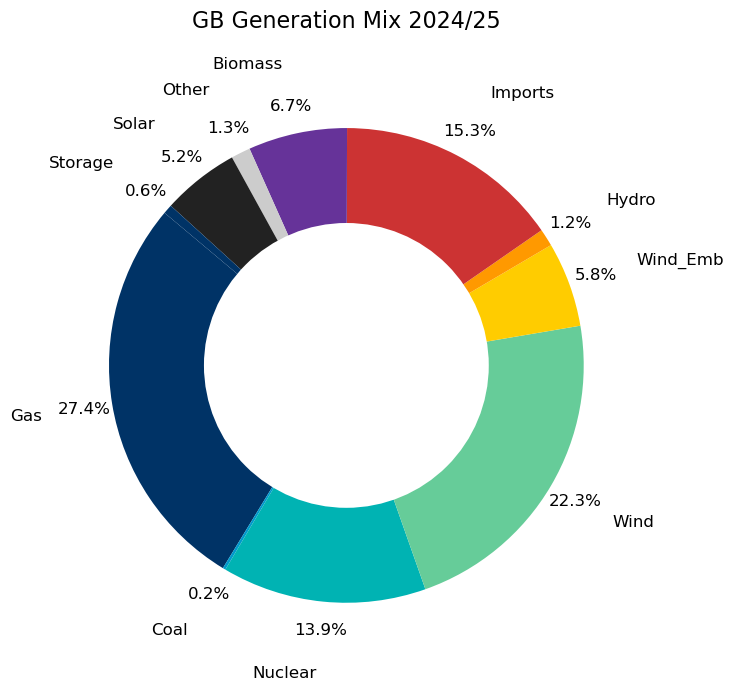

In [9]:
# Pie chart of annual generation percentages

# RMetS color palette:
# Deep Blue, Light Blue, Teal, Green, Yellow, Orange, Red, Purple, Grey, Black
rmets_colors = [
'#003366', '#0099CC', '#00B3B3', '#66CC99', '#FFCC00',
'#FF9900', '#CC3333', '#663399', '#CCCCCC', '#222222'
]

# Convert index to title case for better labels
labels = [label.title() for label in generation_percentages.index]

fig, ax = plt.subplots(figsize=(10, 7))

# Draw the pie chart
wedges, texts, autotexts = ax.pie(
    generation_percentages,
    labels=labels,
    colors=rmets_colors[:len(labels)],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=1.12,
    labeldistance=1.3,
    textprops={'fontsize': 12},
)

# Draw a white circle at the center for a donut look
centre_circle = plt.Circle((0,0),0.60,fc='white')
fig.gca().add_artist(centre_circle)

ax.set_title(f"GB Generation Mix {fy}", fontsize=16, pad=30)
plt.tight_layout()
plt.show();